# Detect Noise

Whether noise is random (highly variable) or spiky (outliers), PyTrendy can detect either and ensure that potentially insightful trends are not overestimated over such periods. In this notebook, the first section covers examples facing Random Noise, and in the second Spikes.

![](https://raw.githubusercontent.com/RussellSB/pytrendy/refs/heads/develop/plots/Noise-Random-Cropped.gif)

![](https://raw.githubusercontent.com/RussellSB/pytrendy/refs/heads/develop/plots/Noise-Spikes-Cropped.gif)

## Installation

Install PyTrendy using pip.

In [23]:
%pip install pytrendy -q

Note: you may need to restart the kernel to use updated packages.


In [24]:
import pytrendy as pt
import numpy as np

## Load Example Data

In this example we use the gradual dataset and modify it for noise edge cases.

In [25]:
# Load a synthetic time series with gradual trends
df = pt.load_data('series_synthetic')[['date', 'gradual']]
df.head()

,date,gradual
0,2025-01-01,12.500000
1,2025-01-02,13.421717
2,2025-01-03,13.474026
3,2025-01-04,13.474026
4,2025-01-05,14.505772


<Axes: xlabel='date'>

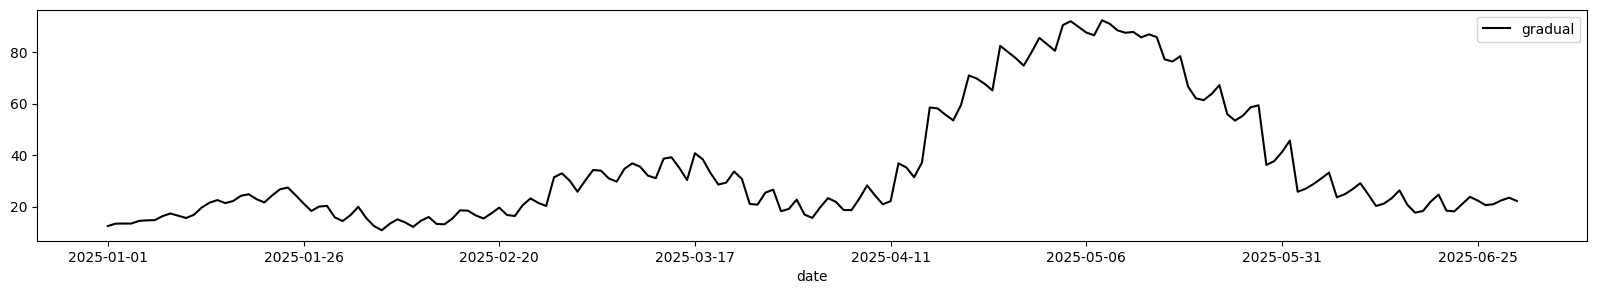

In [26]:
# Visualise the data
df.set_index('date').plot(figsize=(20,3), color='black')

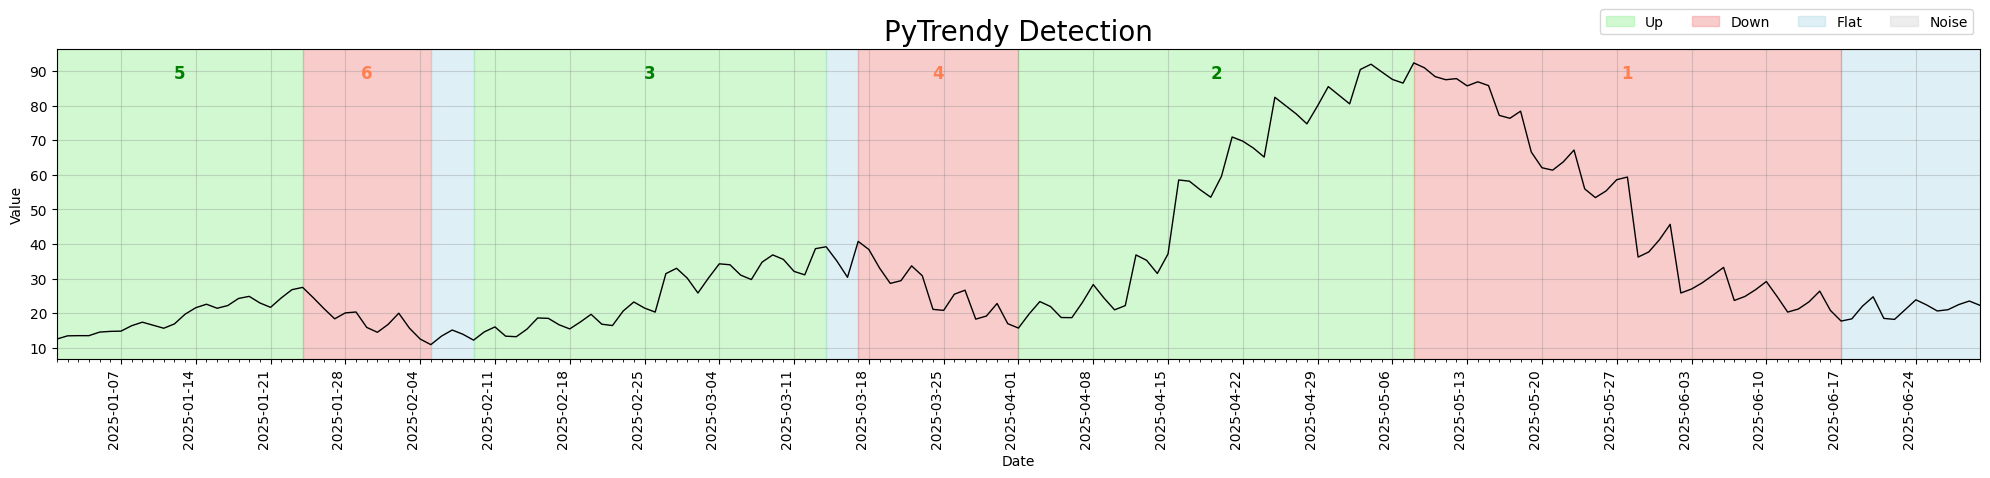

In [27]:
results = pt.detect_trends(df, date_col='date', value_col='gradual', method_params=dict(is_abrupt_padded=True))

Note the originally detected trend periods. These will get affected once we introduce noise.

## Detect Random Noise

### Moderate Noise

We will introduce random noise to the gradual trends via `np.random.normal`.
Centred around a mean of 0, we determine the standard deviation `noise_std` as the main lever for controlling random noise. The higher the standard deviation, the larger the degree of noise. To begin with, we introduce a moderate level of noise with an std of 15.

<Axes: xlabel='date'>

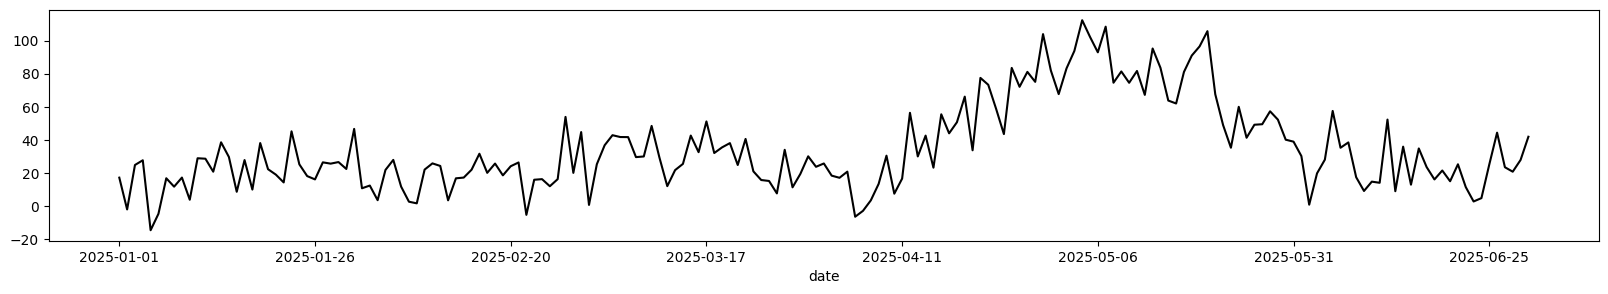

In [28]:
rng = np.random.default_rng(seed=42)

noise_std = 15 # controls the degree of noise
df['gradual_noisy'] = df['gradual'] + rng.normal(0, noise_std, size=len(df))
df.set_index('date')['gradual_noisy'].plot(figsize=(20,3), color=['black'])

Note how much noisier the signal is compared to the previous plot above. 
- The shallow trends in the first half of the signal have become a lot more obfuscated.
- Only the steep trends towards the end of the series are visible.

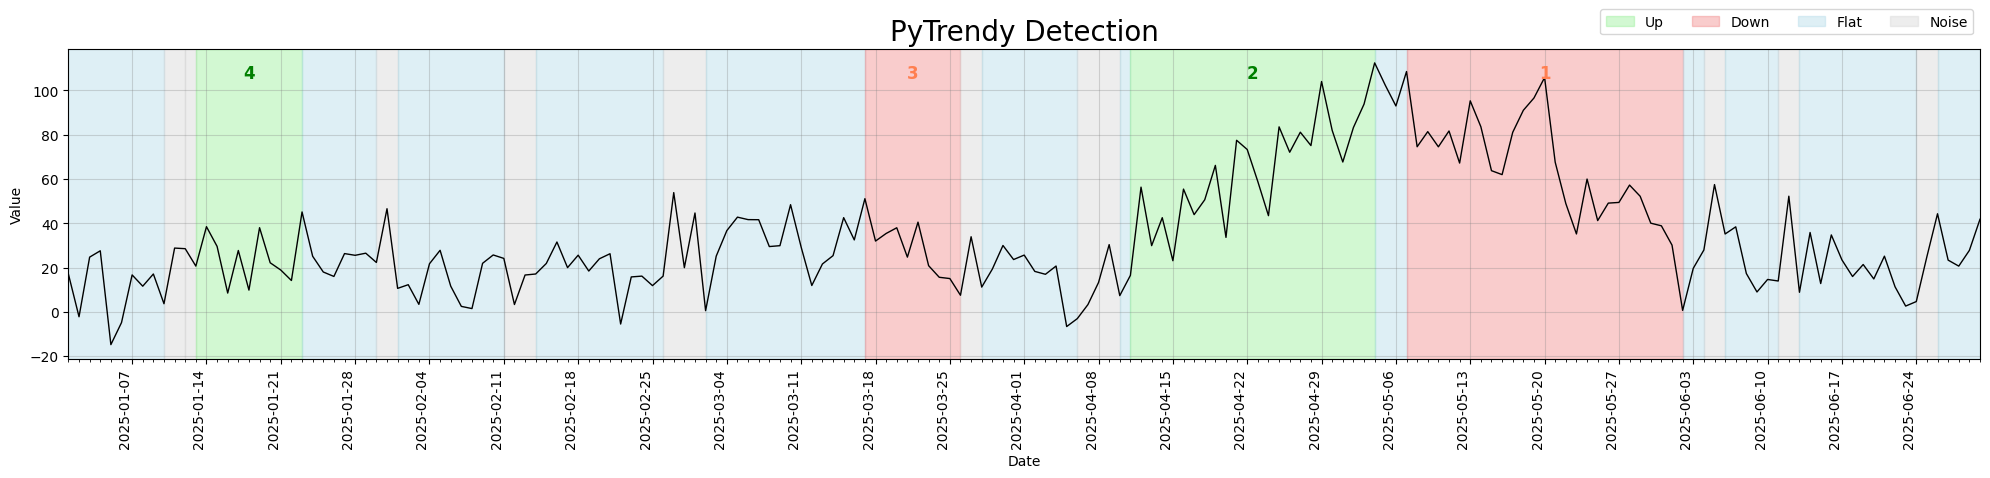

In [29]:
results_noisy = pt.detect_trends(df, date_col='date', value_col='gradual_noisy', method_params=dict(is_abrupt_padded=True))

Noise is detected throughout the dataset, breaking detected trends once too much noise obfuscates their direction.

The trends:
- The steep trends are detected as expected, but shorter in length. Still, they retain their change ranks, 1 for downtrend, and 2 for uptrend.
- Fragments of the shallow trends (now at change rank 3 and 4) are still detected, but at much shorter segments.

The noise:
- Noise is detected, determined by a rolling window of SNR (Signal-to-Noise Ratio).
- Flat is also detected, where the standard deviation happens to equalise the signal to a flat rather than high-variation profile.

Let's further compare the before and after below.

In [30]:
print('Before: ')
display(results.filter_segments(direction='Up/Down', sort_by='change_rank'))
print('After: ')
display(results_noisy.filter_segments(direction='Up/Down', sort_by='change_rank'))

Before: 


,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
8,Down,2025-05-09,2025-06-17,gradual,-73.253968,-0.805442,39,-73.253968,21.122099,1
7,Up,2025-04-02,2025-05-08,gradual,73.687771,3.944243,36,72.611833,21.701162,2
4,Up,2025-02-10,2025-03-14,gradual,26.015512,1.974942,32,24.632035,18.871430,3
6,Down,2025-03-18,2025-04-01,gradual,-22.721861,-0.591909,14,-22.721861,16.762790,4
1,Up,2025-01-02,2025-01-24,gradual,14.013348,1.044080,22,14.013348,22.207980,5
2,Down,2025-01-25,2025-02-05,gradual,-13.564214,-0.554982,11,-13.564214,17.360657,6


After: 


,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
18,Down,2025-05-08,2025-06-02,gradual,-105.059242,-0.993462,25,-73.847240,13.782036,1
16,Up,2025-04-12,2025-05-04,gradual,89.267620,3.863375,22,56.063531,13.374323,2
11,Down,2025-03-18,2025-03-26,gradual,-32.981864,-0.814173,8,-24.450883,12.346699,3
3,Up,2025-01-13,2025-01-23,gradual,36.602086,4.299992,10,24.437607,5.874872,4


Fewer trends have been detected as a result, and the steepest trend has shortened from a length of 39 days to 25 days.

Let's inspect the detected noise segments now.

In [31]:
print('Before: ')
display(results.filter_segments(direction='Noise')) # no noise detected
print('After: ')
display(results_noisy.filter_segments(direction='Noise'))

Before: 


""


After: 


,direction,start,end,days,SNR
time_index,,,,,
2,Noise,2025-01-10,2025-01-12,2,6.710358
5,Noise,2025-01-30,2025-02-01,2,2.855639
7,Noise,2025-02-11,2025-02-14,3,6.294206
9,Noise,2025-02-26,2025-03-02,4,1.965896
12,Noise,2025-03-26,2025-03-28,1,4.008353
14,Noise,2025-04-06,2025-04-10,4,2.384833
20,Noise,2025-06-04,2025-06-06,2,4.504091
22,Noise,2025-06-11,2025-06-13,2,0.750103
24,Noise,2025-06-24,2025-06-26,2,1.756512


After random noise was introduced, 9 segments were detected as noise. Note the SNR. The closer to 0, the more indicative of a noisy signal. PyTrendy works with a noise threshold on SNR to best determine whether a segment is noise or not. Comparing the SNR of noise segments to trends as displayed above, you can clearly see that the more "noisy" the segment, the lower the SNR.

Even the uptrend at change rank 4 has a notably low SNR at 5.8 compared to the other trends with SNR above 10. Visually, you can see the uptrend is not as clearly an uptrend as it once was before noise was introduced. This segment is on the borderline of PyTrendy's custom threshold for what is noise and what isn't. The change rank helps reflect that. As long as there are segments with clearly much less noise and more magnitude, they will always be ranked higher.

### Varying Levels of Noise

We can re-execute this in a loop with increasing levels of noise. As we range from 0 to 50, fewer trends are detected and more segments of flats and noise are detected in their place. Finally, at a sufficiently high level of 50 std, a majority of the series is detected as noise.

Simulating random noise with std: 0


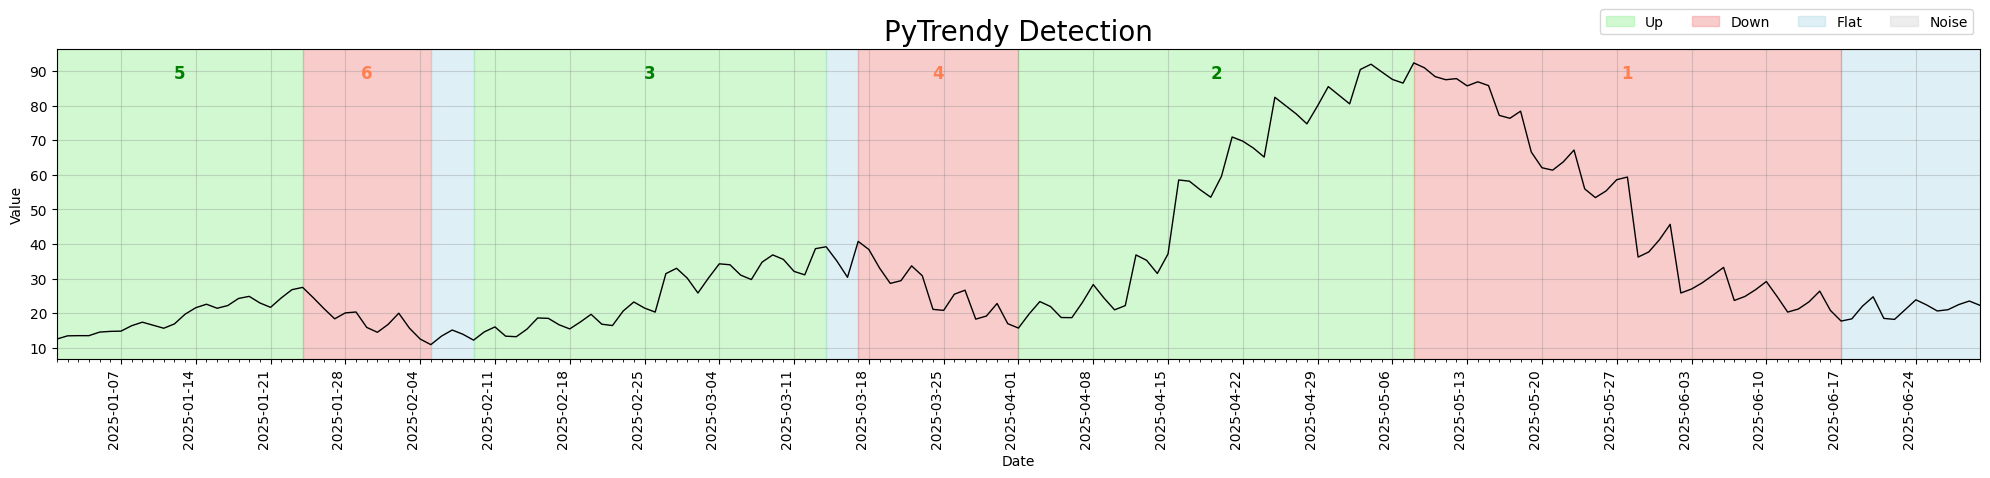

Simulating random noise with std: 10


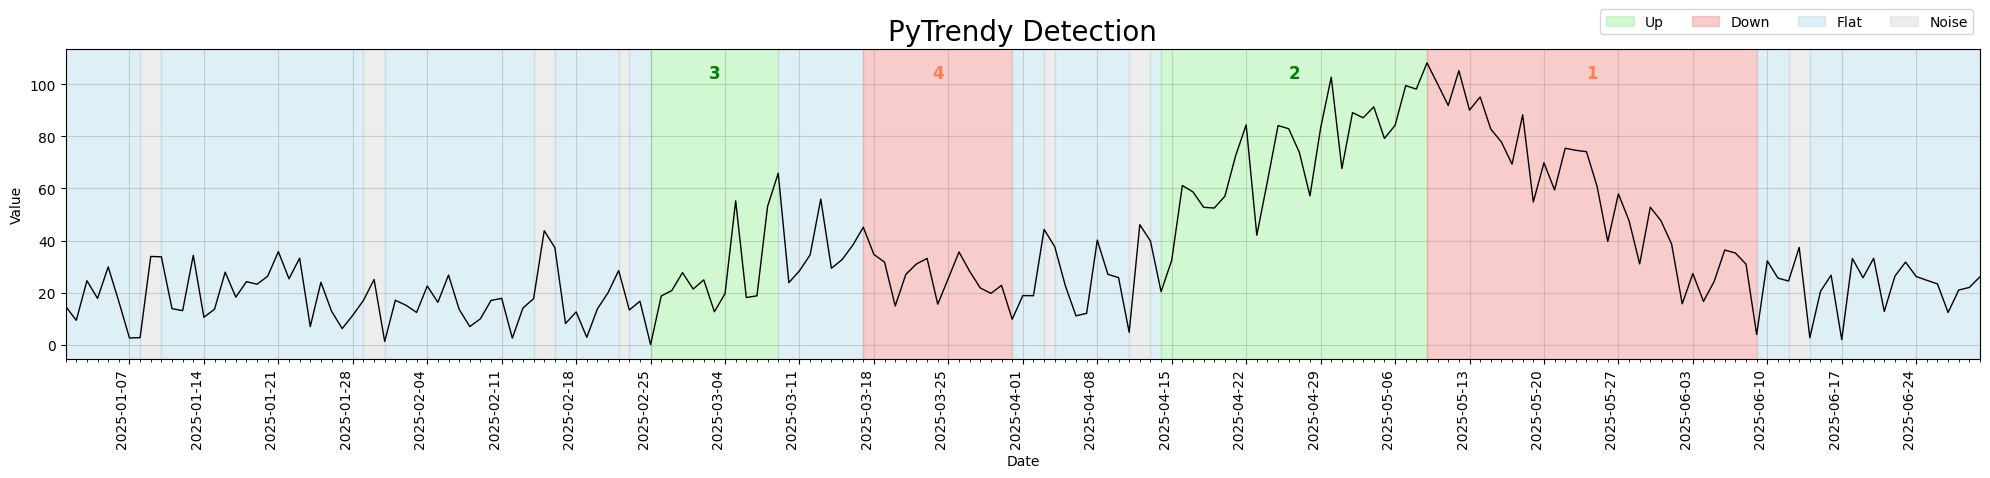

Simulating random noise with std: 20


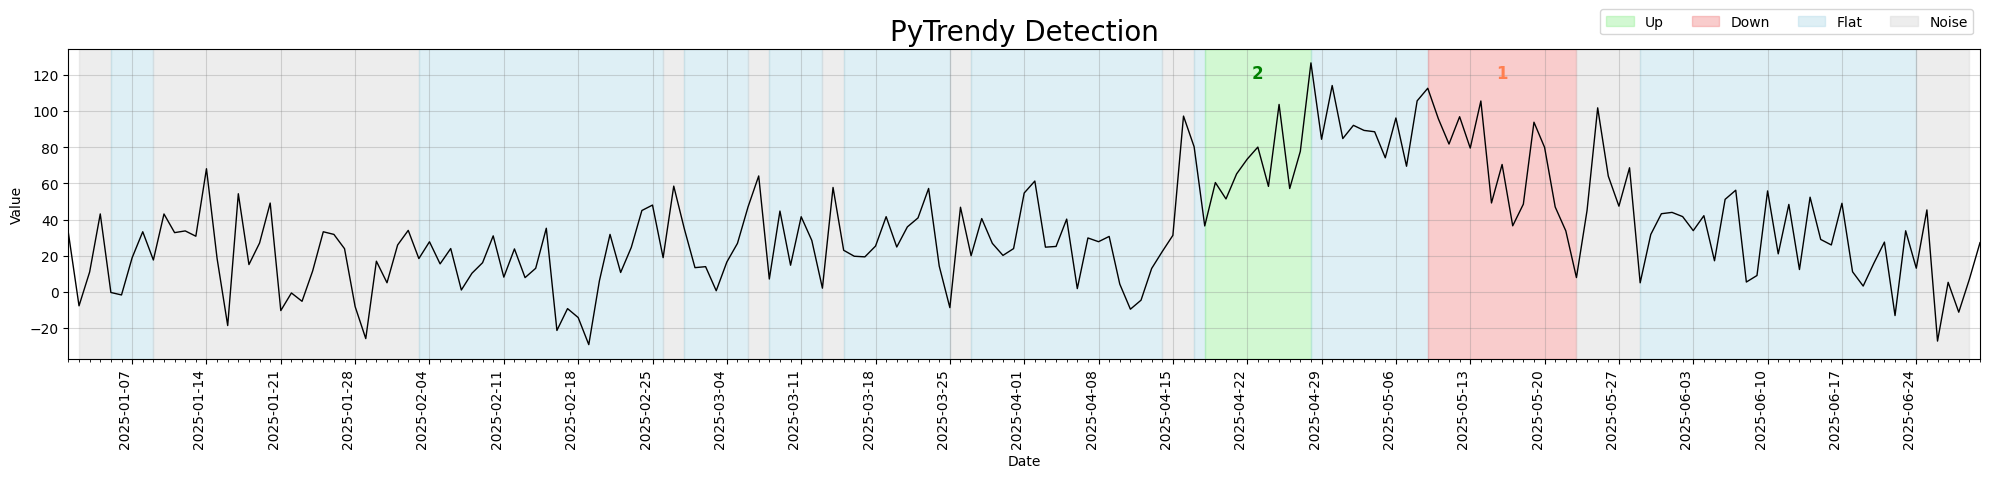

Simulating random noise with std: 50


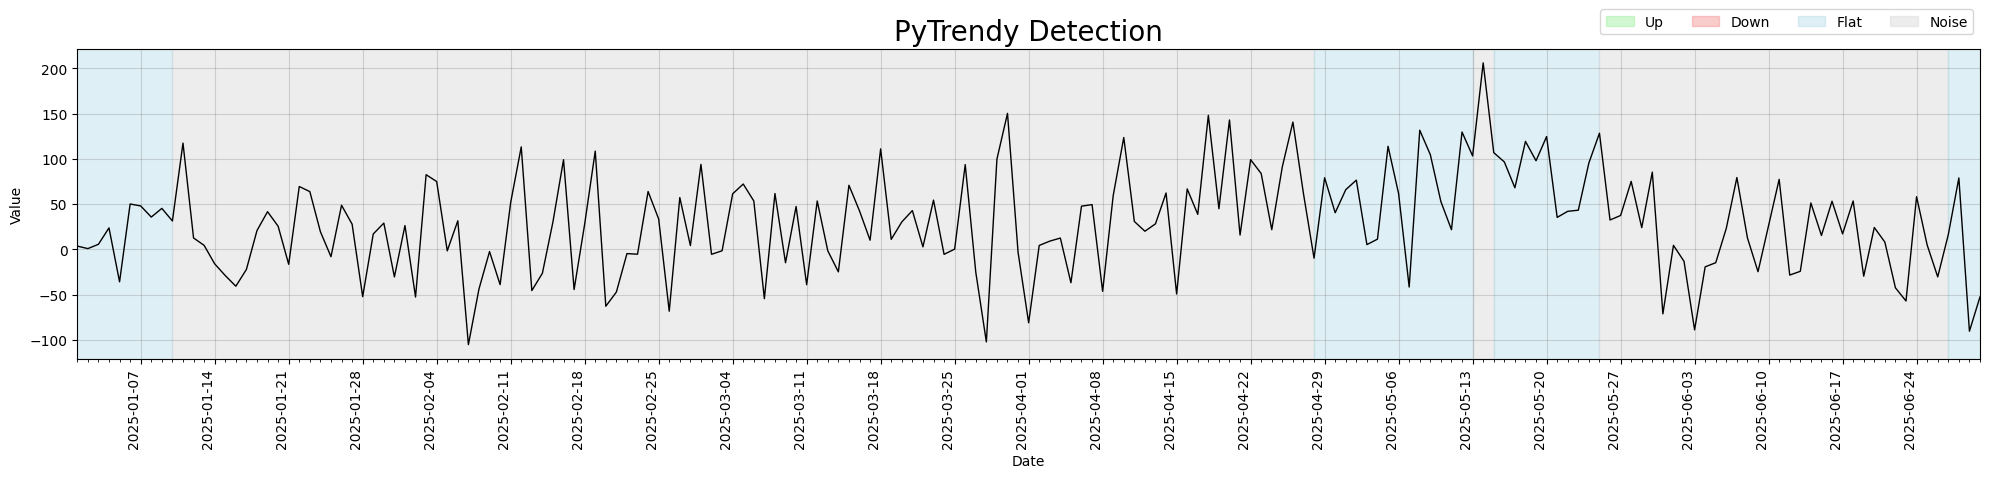

In [32]:
# Compare varying levels of noise
rng = np.random.default_rng(seed=42)

results_varying_levels = {}
for noise_std in [0, 10, 20, 50]:
    print(f'Simulating random noise with std: {noise_std}')
    df['gradual_noisy'] = df['gradual'] + rng.normal(0, noise_std, size=len(df))
    results_varying_levels[noise_std] = pt.detect_trends(df, date_col='date', value_col='gradual_noisy', method_params=dict(is_abrupt_padded=True))

## Detect Spikes

Spikes are another form of noise that could affect the validity of trends. Whether the result of a data entry error, a holiday, or a promotional sales day, it's worth taking this into consideration to avoid false positives in trend detection.

In [33]:
df = df.reset_index()

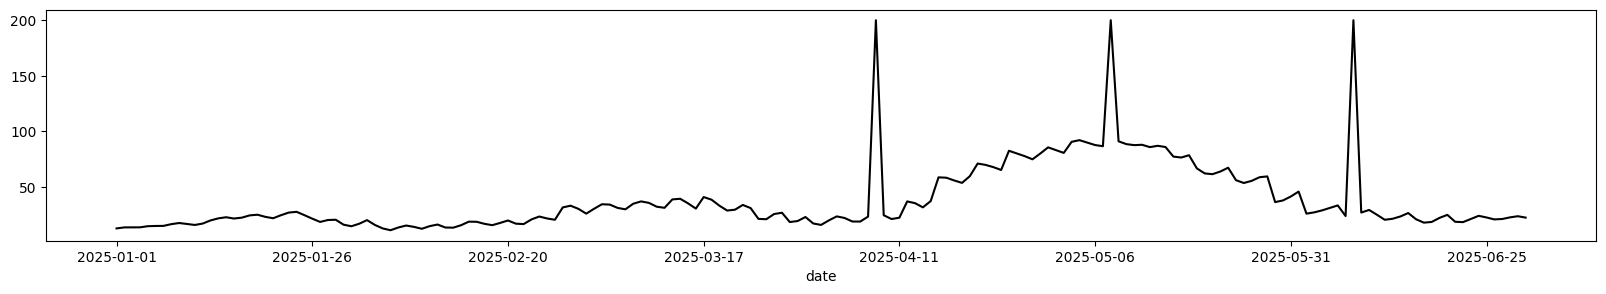

In [34]:
# Prepare the spikes, introducing three around the steep trends
df['gradual_spiky'] = df['gradual']
df.set_index('date', inplace=True)
df.loc['2025-04-08':'2025-04-08', 'gradual_spiky'] = 200 
df.loc['2025-05-08':'2025-05-08', 'gradual_spiky'] = 200 
df.loc['2025-06-08':'2025-06-08', 'gradual_spiky'] = 200 

df['gradual_spiky'].plot(figsize=(20,3), color=['black'])
df = df.reset_index()

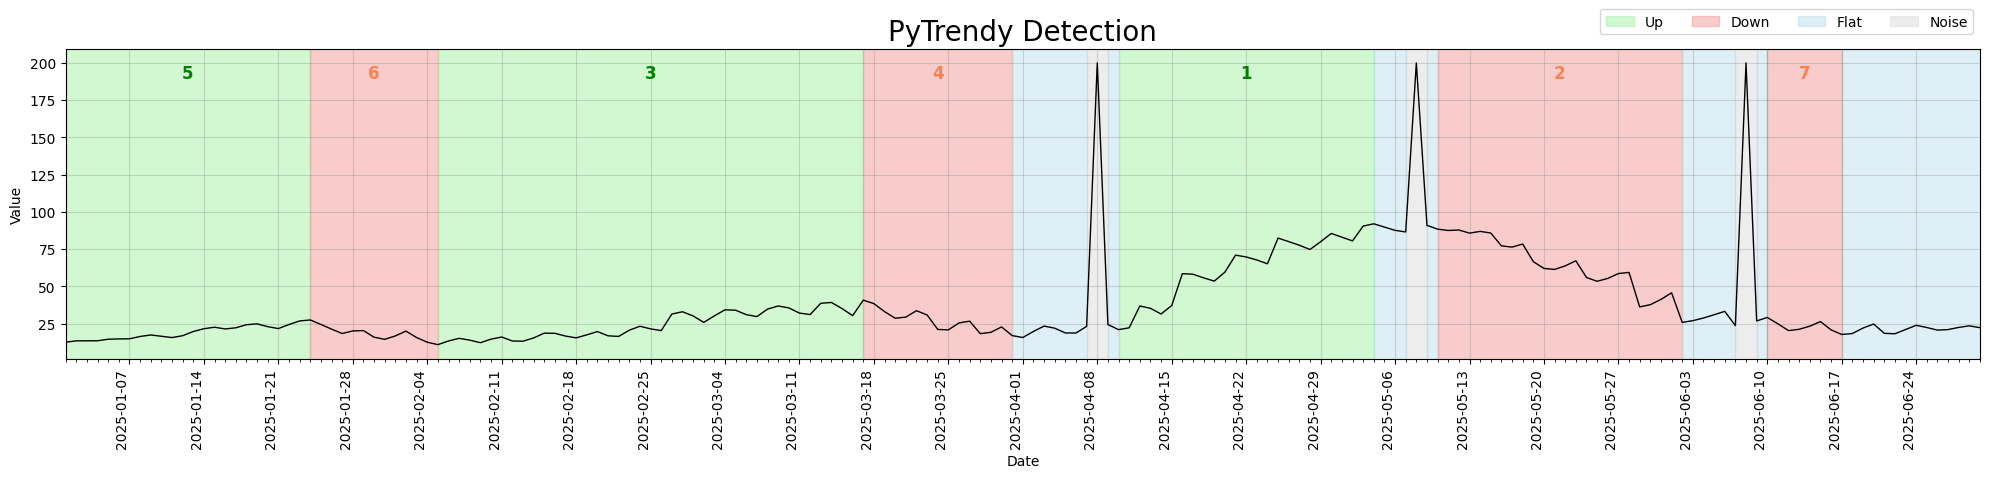

,direction,start,end,days,SNR
time_index,,,,,
6,Noise,2025-04-07,2025-04-09,2,-5.569928
10,Noise,2025-05-07,2025-05-09,2,5.306192
14,Noise,2025-06-07,2025-06-09,2,-4.503185


In [35]:
results_spiky = pt.detect_trends(df, date_col='date', value_col='gradual_spiky')
results_spiky.filter_segments(direction='Noise')


Noise is detected around the periods of introduced outliers. As a result, the trend starts and ends have been shifted so as not to overlap them.

In [36]:
print('Before: ')
display(results.filter_segments(direction='Up/Down')[-2:])
print('After: ')
display(results_spiky.filter_segments(direction='Up/Down')[-3:])


Before: 


,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
7,Up,2025-04-02,2025-05-08,gradual,73.687771,3.944243,36,72.611833,21.701162,2
8,Down,2025-05-09,2025-06-17,gradual,-73.253968,-0.805442,39,-73.253968,21.122099,1


After: 


,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
8,Up,2025-04-11,2025-05-04,gradual,69.817821,3.149471,23,69.817821,17.997799,1
12,Down,2025-05-11,2025-06-02,gradual,-62.012987,-0.706100,22,-61.688312,19.982376,2
16,Down,2025-06-11,2025-06-17,gradual,-8.658009,-0.328542,6,-7.138648,9.102388,7


The final downtrend was split into two as a spike occurred towards its end. Meanwhile, the uptrend remained intact but shortened, with flat periods detected around the spikes that overlapped it.

## Conclusion

PyTrendy can detect two types of noise. In this notebook, we demonstrated how to:

- Detect random noise by injecting normal distributions with varying levels of standard deviation.
- Detect spikes that are anomalous data points which temporarily affect the series.